# Task 1 — Evaluation and Forecasting

This notebook evaluates the baseline purchase prediction pipeline and visualises seasonal demand forecasts for selected products.

In [1]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("../").resolve()
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

print("Project root:", PROJECT_ROOT)
print("Source dir   :", SRC_DIR)

Project root: /Users/spicykiks/Desktop/kiky/Third year second semester/advanced ai/UFCFUR-15-3---Advanced-artificial-intelligence/task1_purchase_prediction
Source dir   : /Users/spicykiks/Desktop/kiky/Third year second semester/advanced ai/UFCFUR-15-3---Advanced-artificial-intelligence/task1_purchase_prediction/src


## 1. Import Forecasting Function

In [2]:
from predict import forecast_demand

## 2. Generate Forecasts for Two Products

In [3]:
tomatoes_forecast = forecast_demand("Tomatoes", months_ahead=4)
milk_forecast = forecast_demand("Milk", months_ahead=4)

tomatoes_df = pd.DataFrame(tomatoes_forecast)
milk_df = pd.DataFrame(milk_forecast)

print("Tomatoes forecast:")
display(tomatoes_df)

print("Milk forecast:")
display(milk_df)

Tomatoes forecast:


,month,expected_demand,trend
0,2025-01,89.79,up
1,2025-02,44.09,down
2,2025-03,129.88,up
3,2025-04,172.17,up


Milk forecast:


,month,expected_demand,trend
0,2025-01,261.71,up
1,2025-02,196.92,down
2,2025-03,210.63,down
3,2025-04,262.85,up


## 3. Plot Forecast Comparison

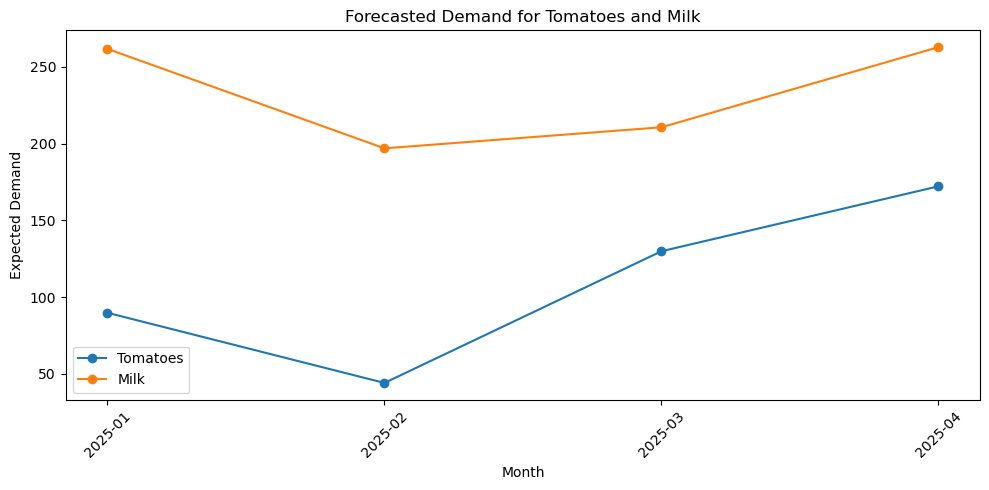

In [4]:
plt.figure(figsize=(10, 5))
plt.plot(tomatoes_df["month"], tomatoes_df["expected_demand"], marker="o", label="Tomatoes")
plt.plot(milk_df["month"], milk_df["expected_demand"], marker="o", label="Milk")
plt.title("Forecasted Demand for Tomatoes and Milk")
plt.xlabel("Month")
plt.ylabel("Expected Demand")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## Findings — Forecasting

- The forecast uses historical monthly quantity totals for each product.
- A seasonal average is learned from the same calendar month across the dataset.
- A simple linear trend is added to capture whether demand has recently been moving upward or downward.
- This is a lightweight baseline forecast, not a full time-series model, so it is suitable for coursework baseline analysis but not for serious production demand planning.